Merging the Residual data to the data Returned from BLAST API

In [2]:
import pandas as pd

# Load both CSVs
df_props = pd.read_csv(
    "/Users/pittsburghgraduatestudent/repos/first_paper_blast_webapi/data_ZTF/ZTF_BLAST_matches_props_v2_ALL_HOST_PROPERTIES_LC_OK.csv"
)
df_resid = pd.read_csv(
    "/Users/pittsburghgraduatestudent/repos/first_paper_blast_webapi/data_ZTF/ZTF_residuals_centered.csv"
)

# Merge only the 'residual_centered' column from df_resid, matching on 'ztfname'
df_merged = df_props.merge(
    df_resid[["ztfname", "residual_centered"]],
    on="ztfname",
    how="left"  # keeps all rows from df_props
)

# Save to a new CSV
df_merged.to_csv(
    "/Users/pittsburghgraduatestudent/repos/first_paper_blast_webapi/data_ZTF/ZTF_BLAST_with_residuals.csv",
    index=False
)

print("✅ Merged file saved successfully.")
print(f"Shape: {df_merged.shape}")

✅ Merged file saved successfully.
Shape: (1279, 52)


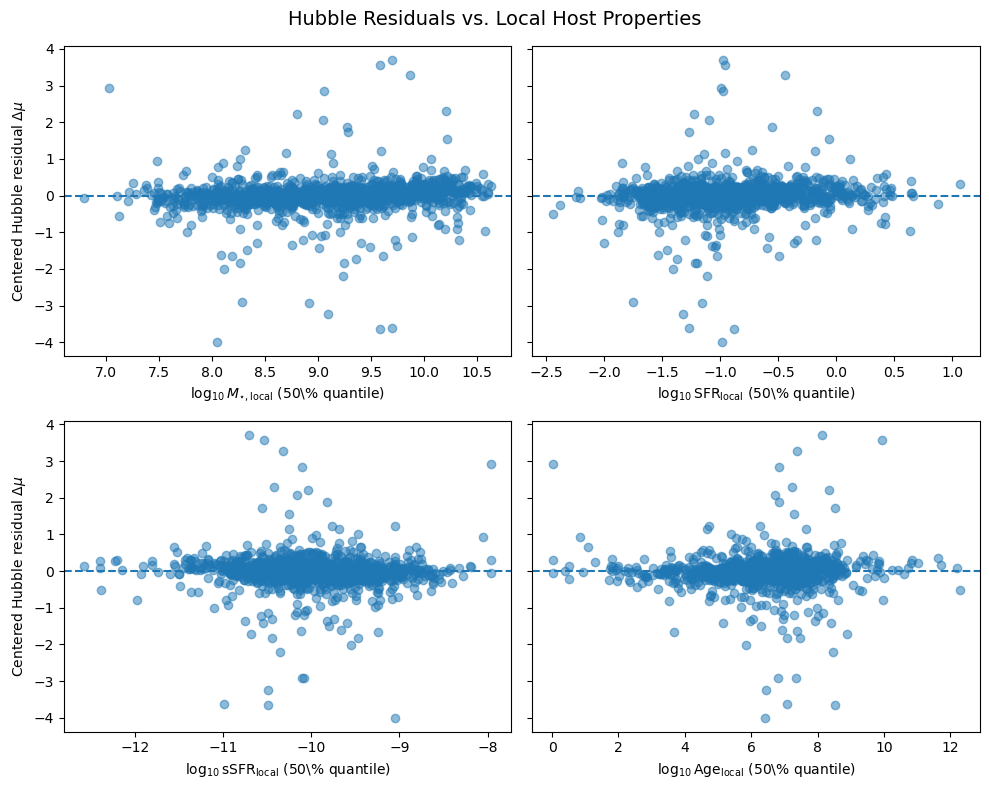

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the merged file
df = pd.read_csv(
    "/Users/pittsburghgraduatestudent/repos/first_paper_blast_webapi/data_ZTF/ZTF_BLAST_with_residuals.csv"
)

# Optional: drop rows where residual_centered is NaN
df = df.dropna(subset=["residual_centered"])

# Set up 2x2 grid of scatter plots
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)
fig.suptitle("Hubble Residuals vs. Local Host Properties", fontsize=14)

# 1) residual_centered vs blast_local_log_mass_50
ax = axes[0, 0]
ax.scatter(df["blast_local_log_mass_50"], df["residual_centered"], alpha=0.5)
ax.axhline(0, linestyle="--")
ax.set_xlabel(r"$\log_{10} M_{\star,\mathrm{local}}$ (50\% quantile)")
ax.set_ylabel(r"Centered Hubble residual $\Delta \mu$")

# 2) residual_centered vs blast_local_log_sfr_50
ax = axes[0, 1]
ax.scatter(df["blast_local_log_sfr_50"], df["residual_centered"], alpha=0.5)
ax.axhline(0, linestyle="--")
ax.set_xlabel(r"$\log_{10} \mathrm{SFR}_{\mathrm{local}}$ (50\% quantile)")

# 3) residual_centered vs blast_local_log_ssfr_50
ax = axes[1, 0]
ax.scatter(df["blast_local_log_ssfr_50"], df["residual_centered"], alpha=0.5)
ax.axhline(0, linestyle="--")
ax.set_xlabel(r"$\log_{10} \mathrm{sSFR}_{\mathrm{local}}$ (50\% quantile)")
ax.set_ylabel(r"Centered Hubble residual $\Delta \mu$")

# 4) residual_centered vs blast_local_log_age_50
ax = axes[1, 1]
ax.scatter(df["blast_local_log_age_50"], df["residual_centered"], alpha=0.5)
ax.axhline(0, linestyle="--")
ax.set_xlabel(r"$\log_{10} \mathrm{Age}_{\mathrm{local}}$ (50\% quantile)")

plt.tight_layout()
plt.show()